In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
import torch
import torch.nn as nn   
import torch.optim as optim

from torch.optim import SGD

from torch.utils.data import DataLoader, TensorDataset

from sklearn.cluster import KMeans

Input and target data:

Masking the wavelength grid

In [3]:
final_wave = 3536. + np.arange(4306) * 0.9
original_wave = 3500. + np.arange(4367) * 0.9

In [4]:
low_idx = np.argmin(abs(original_wave - final_wave[0]))
high_idx = np.argmin(abs(original_wave - final_wave[-1]))

In [5]:
preprocessed_flux = np.load("../preprocessing/cflib_data.npz", allow_pickle= True)["flux"]

input_flux = []

for i in range(len(preprocessed_flux)):
    input_flux.append(preprocessed_flux[i][low_idx : high_idx + 1])
    
input_flux = np.array(input_flux)

# input_flux = np.load("../preprocessing/preprocess_cflib_vyom.npy")   # input of vyom preprocessed data

target_flux = np.load("rf_interpolated_fluxes.npy")

print(len(target_flux[0]))  # checking the length of the interpolated flux arrays
print(input_flux)
print(target_flux)


4306
[[1.1825487646914092 1.1841432511841439 1.1860783470682998 ...
  0.4124035574007773 0.4105880111693166 0.4107658742488486]
 [0.05012359158249259 0.05087644314420091 0.05242872825483944 ...
  1.470013205194036 1.4559561793877915 1.4632705648224837]
 [0.2362234472559823 0.23218703652067837 0.23380249477842624 ...
  0.7866333409396982 0.7716400516481633 0.7752994451876409]
 ...
 [0.6531245140554456 0.6494315947886485 0.6536496646603588 ...
  9.85354519046036e-05 9.85354519046036e-05 9.85354519046036e-05]
 [0.40733122403375077 0.38788939127494076 0.39513174101918763 ...
  9.190256391646997e-05 9.190256391646997e-05 9.190256391646997e-05]
 [0.6186189577056762 0.622308238396077 0.6300363299913472 ...
  0.6388013675444142 0.6380960935140043 0.6365599939693225]]
[[1.18601767 1.22942634 1.17626099 ... 0.42062923 0.42171141 0.42278666]
 [0.09260631 0.10392712 0.1085579  ... 1.89134097 1.89760813 1.91798774]
 [0.12836964 0.1376427  0.13979537 ... 0.82752983 0.81743293 0.82009242]
 ...
 [0.78

Checking for the order of the flux data of stars

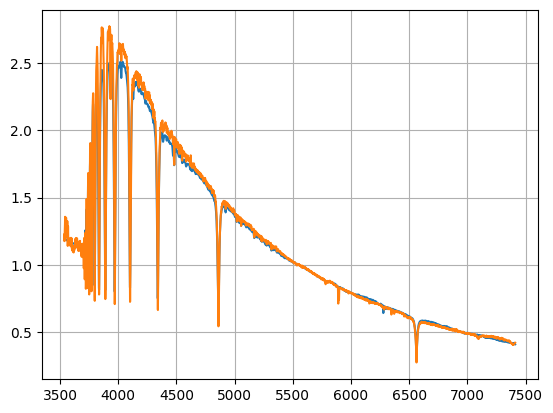

In [6]:
plt.plot(final_wave,input_flux[0])
plt.plot(final_wave,target_flux[0])
plt.grid()

Checking the number of clusters in the data : 

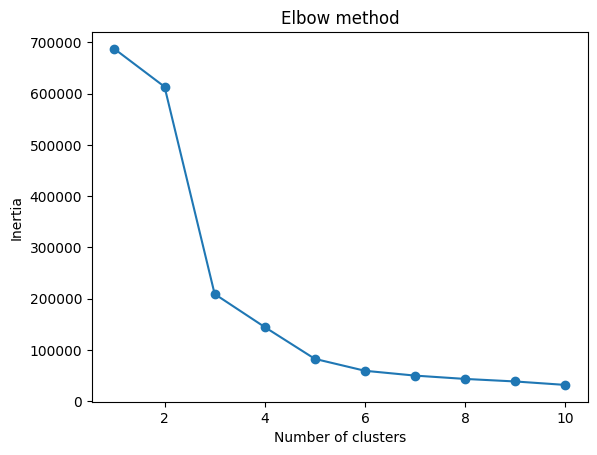

In [7]:
inertia_list = []

for k in range(1,11):

    k_classification = KMeans(n_clusters= k)
    k_classification.fit(input_flux)

    inertia_list.append(k_classification.inertia_)

plt.plot(range(1,11), inertia_list, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()



k = 5

In [8]:
input_flux = np.array(input_flux, dtype=np.float32)    

Splitting the data in training and testing data : 

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(input_flux,target_flux, test_size= 0.2, random_state = 42)

X_val,X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42)

In [10]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(680, 4306)
(85, 4306)
(85, 4306)


Switching from CPU cores to CUDA cores :

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Initializing the Denoising Auto Encoder :

In [12]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim = 4306, latent_dim = 16):
        super(DenoisingAutoencoder, self).__init__()

        # initializing the latent space

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 951),
            nn.ReLU(),
            nn.Linear(951,128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 951),
            nn.ReLU(),
            nn.Linear(951, input_dim),
        )

    # x here is a datapoint --> in our case a rank one tensor (datapoint vector)
    
    def forward(self, x):       
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return decoded

def add_noise(x, noise_factor = 0.0268):      # add a gaussian noise to the data vector 
    noise = noise_factor * torch.randn_like(x)       # choose a random tensor with a same shape as X from a standard normal distribution
    return x + noise
    


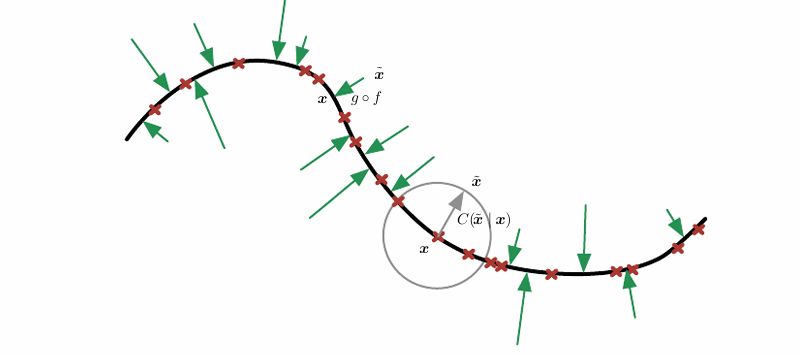

The gray circle is the noise circle that has noise mappings of real input values on the circumference.

Defining the model 

In [13]:
model = DenoisingAutoencoder()
model.to(device)    # shifting the model to CUDA cores

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=4306, out_features=951, bias=True)
    (1): ReLU()
    (2): Linear(in_features=951, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=951, bias=True)
    (3): ReLU()
    (4): Linear(in_features=951, out_features=4306, bias=True)
  )
)

In [14]:
model.parameters()

<generator object Module.parameters at 0x7b9b23c8fe60>

Initializing the ADAM optimizer 

In [15]:
optimizer = optim.Adam(model.parameters(), lr= 0.0043)

loss_fn = nn.MSELoss()      # MSE as the loss functon


In [16]:
X_train_tensor = torch.tensor(X_train, dtype= torch.float32).to(device= device)       # converting the input data to tensor , in out case , each input datapoint is a rank 1 tensor (vector)
y_train_tensor = torch.tensor(y_train, dtype= torch.float32).to(device= device)

X_val_tensor = torch.tensor(X_val, dtype= torch.float32).to(device= device)
y_val_tensor = torch.tensor(y_val, dtype= torch.float32).to(device= device)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

dataset = TensorDataset(X_train_tensor,y_train_tensor)

Creating a joint pair and wrapping the dataset to enable mini-batch training : 

In [17]:
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)    
val_loader   = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32)
test_loader  = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32)

Training loop and optimizing model parameters using backpropagation and ADAM :

In [18]:
loss_list = []
validation_list = []
for epoch in range(1,1001):
    model.train()           # setting the model to training mode
    running_loss = 0      # initializing a running loss for each epoch


    for x_batch,y_batch in train_loader:          # running loop for different batches in each epoch
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        noisy_input = add_noise(x_batch)           # adding noise to the input batch
        output = model(x_batch)

        loss = loss_fn(output, y_batch)     # calculating the loss function for each batch in an epoch 

        optimizer.zero_grad()       # clears the gradients from previous batch
        loss.backward()         # computes the gradient of the loss function with respect to the parameter/s we want to optimize
        optimizer.step()       # take a small step towards the better value of the parameter

        running_loss += loss        # summing up total loss of all the batches

    print(f"Epoch number : {epoch}, loss = {running_loss}")

    if running_loss < 0.02:     # setting up a threshold for epochs (early stopping)
        break

    model.eval()           # putting the model in validation mode
    val_loss = 0.0          # initializing the validation loss

    with torch.no_grad():       # no backward propagation
        for x_val_batch, y_val_batch in val_loader:

            x_val_batch = x_val_batch.to(device)    # shifting from cpu to CUDA
            y_val_batch = y_val_batch.to(device)

            noisy_val_input = add_noise(x_val_batch)
            output = model(x_val_batch)

            loss = loss_fn(output, y_val_batch)

            val_loss += loss
        
    print(f"Epoch number : {epoch}, val_loss = {val_loss}")

    loss_list.append(running_loss)
    validation_list.append(val_loss)

Epoch number : 1, loss = 20.084959030151367
Epoch number : 1, val_loss = 0.27239325642585754
Epoch number : 2, loss = 2.227719783782959
Epoch number : 2, val_loss = 0.10391830652952194
Epoch number : 3, loss = 1.0939902067184448
Epoch number : 3, val_loss = 0.04642467200756073
Epoch number : 4, loss = 0.724570095539093
Epoch number : 4, val_loss = 0.05338030681014061
Epoch number : 5, loss = 0.6358758807182312
Epoch number : 5, val_loss = 0.037675853818655014
Epoch number : 6, loss = 0.6899965405464172
Epoch number : 6, val_loss = 0.04882223904132843
Epoch number : 7, loss = 0.9196683168411255
Epoch number : 7, val_loss = 0.052438586950302124
Epoch number : 8, loss = 0.636396586894989
Epoch number : 8, val_loss = 0.038756754249334335
Epoch number : 9, loss = 0.5072427988052368
Epoch number : 9, val_loss = 0.038308653980493546
Epoch number : 10, loss = 0.4858492612838745
Epoch number : 10, val_loss = 0.0379972830414772
Epoch number : 11, loss = 1.0388671159744263
Epoch number : 11, val_

Plotting the learning curve for training :

In [19]:
learning_list = []
for i in range(len(loss_list)):
    learning_list.append(loss_list[i].item())

val_list = []

for i in range(len(validation_list)):
    val_list.append(validation_list[i].item())

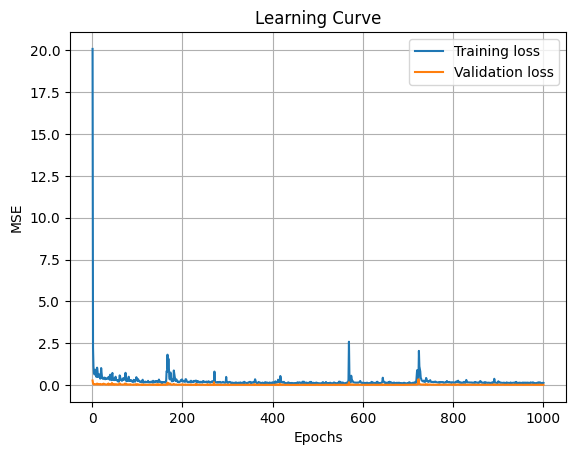

In [20]:
sns.lineplot(x = np.linspace(1,len(learning_list), len(learning_list)), y = learning_list, label = "Training loss")
sns.lineplot(x = np.linspace(1, len(val_list), len(val_list)), y = val_list, label = "Validation loss")
plt.title("Learning Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.grid()

Learning curve for given hyperparameters 

#### Testing the model by fitting it on an input test set :

In [21]:

model.eval()

with torch.no_grad():
    output = model(X_test_tensor)
output

tensor([[0.2067, 0.2638, 0.2688,  ..., 0.7262, 0.7066, 0.6846],
        [0.1727, 0.2293, 0.2329,  ..., 0.7383, 0.7185, 0.6973],
        [1.5587, 1.7362, 1.7603,  ..., 0.4039, 0.4069, 0.4025],
        ...,
        [0.0689, 0.0929, 0.1093,  ..., 2.8280, 2.8295, 2.7924],
        [0.6084, 0.6985, 0.7128,  ..., 0.6034, 0.5981, 0.5831],
        [0.2674, 0.3255, 0.3328,  ..., 0.7046, 0.6853, 0.6619]],
       device='cuda:0')

In [22]:
print(len(output))

85


In [23]:
print(y_test)

[[0.22653845 0.23553125 0.25101833 ... 0.77336275 0.77122627 0.73711437]
 [0.18646519 0.20779154 0.21280333 ... 0.67769792 0.54843707 0.45333832]
 [1.47035345 1.67129702 1.65152798 ... 0.38688303 0.38839878 0.38585147]
 ...
 [0.05419838 0.0611256  0.06037374 ... 2.46640417 2.45538652 2.45732144]
 [0.63979225 0.71566886 0.73442494 ... 0.58872614 0.58401146 0.584234  ]
 [0.20620743 0.25074193 0.24768466 ... 0.73672486 0.73040322 0.65913094]]


In [24]:
decoded_flux = output.cpu().numpy()     # converting array to numpy format

In [25]:
for i in range(len(target_flux)):
    if np.array_equal(y_test[0], target_flux[i]):
        print(i)

for i in range(len(target_flux)):
    if np.array_equal(y_test[1], target_flux[i]):
        print(i)

star_names = np.load("../preprocessing/cflib_data.npz", allow_pickle= True)["fname"]   
print(star_names[512], star_names[357])

174
731
36130.fits 189944.fits


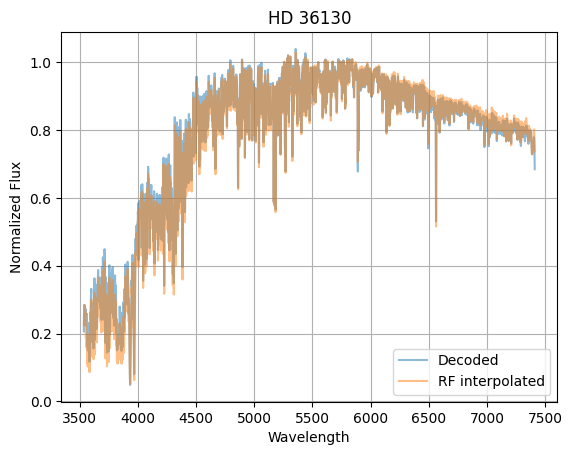

In [26]:
plt.title("HD 36130")
plt.plot(final_wave,decoded_flux[0], label = "Decoded", alpha = 0.5)
plt.plot(final_wave,y_test[0], alpha = 0.5, label = "RF interpolated")
plt.grid()
plt.xlabel("Wavelength")
plt.ylabel("Normalized Flux")
plt.legend()


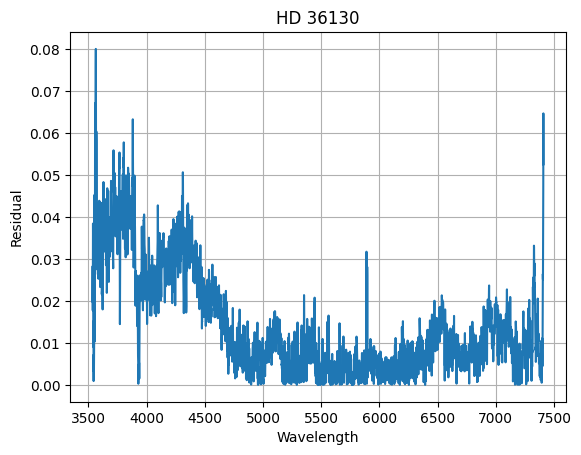

In [27]:
plt.title("HD 36130")
plt.plot(final_wave, np.abs(decoded_flux[0] - y_test[0]))
plt.xlabel("Wavelength")
plt.ylabel("Residual")
plt.grid()

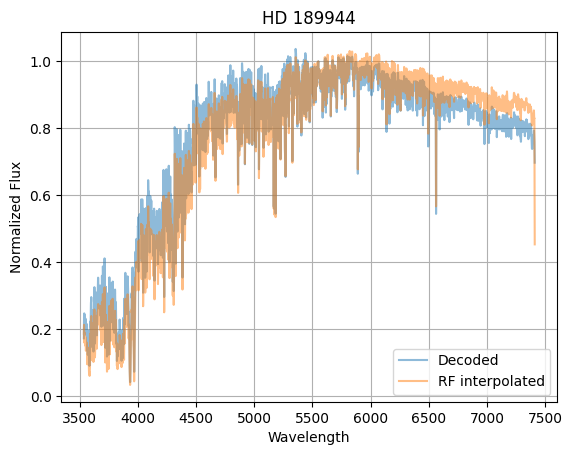

In [28]:
plt.title("HD 189944")
plt.plot(final_wave,decoded_flux[1], label = "Decoded", alpha = 0.5)
plt.plot(final_wave,y_test[1], alpha = 0.5, label = "RF interpolated")
plt.grid()
plt.xlabel("Wavelength")
plt.ylabel("Normalized Flux")
plt.legend()

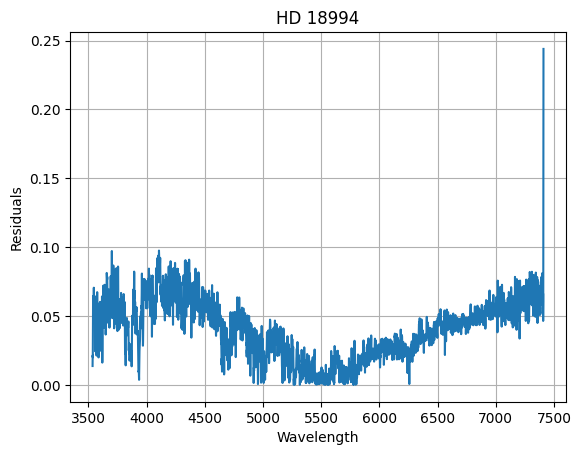

In [29]:
plt.title("HD 18994")
plt.plot(final_wave, np.abs(decoded_flux[1] - y_test[1]))
plt.xlabel("Wavelength")
plt.ylabel("Residuals")
plt.grid()

Reconstruction error (MSE) for the DAE : 

In [30]:
recon_mse = ((decoded_flux - y_test)**2).mean(axis = 0)
recon_mse

array([0.01841445, 0.02788119, 0.03485938, ..., 0.04855411, 0.04707924,
       0.04921196], shape=(4306,))

#### Plotting reconstruction error for different fluxes for all the stars:

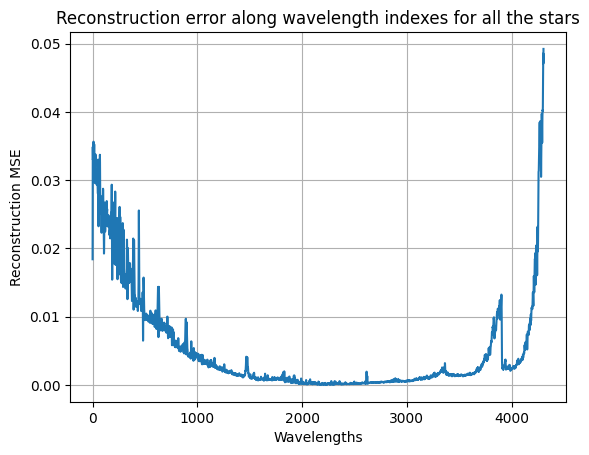

In [39]:
flux_mse = ((decoded_flux - y_test)**2).mean(axis = 0)

plt.title("Reconstruction error along wavelength indexes for all the stars")
plt.xlabel("Wavelengths")
plt.ylabel("Reconstruction MSE")

plt.grid()
plt.plot(flux_mse)
plt.show()


### Hyperparameter Tuning : 

In [32]:
import optuna 

/home/arbiter/projects/Recalibration-deep-learning/.env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Defining the model : 

In [33]:
class DAE(nn.Module):

    '''
    Defining model for hyperparameter tuning : \n

    Object Args: \n

    Input dims : input dimensions   --> int \n 

    Hidden dims : dimensions of hidden layers --> list
    \n
    latent dim: Dimension of latent space --> int
    '''


    def __init__(self, input_dim, hidden_dims, latent_dim):

        super().__init__()

        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.latent_dim = latent_dim


        encoder_layers = []             # defining a list of encoder layers
        last_dim = input_dim          
        for i in self.hidden_dims:
            encoder_layers.append(nn.Linear(last_dim, i))       # append linear layer at each interation
            encoder_layers.append(nn.ReLU())            # append activation function at each iteration

            last_dim = i        # assigning the first dimension value to the last dimension value

        encoder_layers.append(nn.Linear(last_dim, latent_dim))      # add the last latent linear layer

        self.encoder = nn.Sequential(*encoder_layers)       # passing the encoder list as args to sequential to create the encoder network

        decoder_layers = []         # Initializing a list of decoder layers 

        last_dim = latent_dim
        for j in reversed(self.hidden_dims):
            decoder_layers.append(nn.Linear(last_dim, j))
            decoder_layers.append(nn.ReLU())

            last_dim = j

        decoder_layers.append(nn.Linear(last_dim, input_dim))

        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, x):           # forward pass function 

        z = self.encoder(x)

        return self.decoder(z)
    

def add_noise(x, noise_factor):         # adding gaussian noise
    '''
    Adds noise to an array
    \n
    Args : \n
    x : array \n
    noise_factor : noise factor --> int \n

    returns : Gaussian noise 

    '''
    return x + noise_factor * torch.randn_like(x)


Training and validating for hyperparameter tuning : 

In [34]:
def train_and_validate(model, noise_factor, optimizer, epochs):
    '''
    Returns Validation loss \n

    args :\n

    model : model --> Class \n

    noise_factor : noise_factor --> float \n

    optimizer : parameter optimizer for the model --> Class \n

    epochs : number of epochs to run --> int \n

    '''
    for epoch in range(epochs):

        model.train()               # training mode
        for x_batch, y_batch in train_loader:       # 
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            noisy_input = add_noise(x = x_batch, noise_factor= noise_factor)
            output = model(noisy_input)

            loss = loss_fn(output, y_batch) 

            optimizer.zero_grad()       # clears the gradients from previous batch
            loss.backward()         # computes the gradient of the loss function with respect to the parameter/s we want to optimize
            optimizer.step()       # take a small step towards the better value of the parameter

        model.eval()            # validation mode
        validation_loss = 0.0


        with torch.no_grad():
            for x_val_batch, y_val_batch in val_loader:
                x_val_batch = x_val_batch.to(device)
                y_val_batch = y_val_batch.to(device)

                noisy_val_input = add_noise(x_val_batch, noise_factor= noise_factor)
                output_val = model(noisy_val_input)

                loss = loss_fn(y_val_batch, output_val)

                validation_loss += loss

        return validation_loss


Checking a dummy structure of encoder and decoder networks

In [35]:
encode = DAE(input_dim = 4306, hidden_dims = [1024,512,256], latent_dim= 16)
encode

DAE(
  (encoder): Sequential(
    (0): Linear(in_features=4306, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU()
    (6): Linear(in_features=1024, out_features=4306, bias=True)
  )
)

##### Creating a hyperparameter space for bayesian hyperparameter tuning 

Using the TPE (Tree-structured Parzen Estimator) as the sampler to sample the hyperparameter values

In [36]:
# def objective(trial):

#     num_layers = trial.suggest_int("num_layers",2,3,4) # number of layers

#     hidden_dims = [trial.suggest_int(f"hidden_{i}", 128, 1024) for i in range(num_layers)] # assigning(suggest) different values for each layer

#     latent_dim = trial.suggest_categorical("latent_dim", [16, 32, 64, 128]) # suggest the dimension for the latent layer

#     lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)    # learning rate

#     noise = trial.suggest_float("noise", 0.001, 0.05)   # noise factor    

#     model = DAE(input_dim= 4306, hidden_dims = hidden_dims, latent_dim= latent_dim).to(device)   # initialized model
    
#     optimizer = optim.Adam(model.parameters(), lr = lr)     # setting up the optimizer 

#     val_loss = train_and_validate(model = model, noise_factor = noise ,optimizer = optimizer , epochs = 1000)       # validation loss

#     return val_loss


# study = optuna.create_study(direction = "minimize")     # creating study object to optimize 
# # optimizing in the minimizing direction since we want to minimize the validation loss which is the result of the objective function
# study.optimize(objective, n_trials = 30)    # trial -> a single execution of ojective function



In [37]:
# study.best_params       # getting the set of best hyperparameters 

### Getting the stars with high MSE errors in high and low wavelength ranges 

In [41]:
# defining low and high wavelength ranges

low_range = range(0,500)
high_range = range(3806, 4306)

In [ ]:
recon_square_error = (decoded_flux - y_test)**2     # define the reconstructio error

In [ ]:
low_error = recon_square_error[:, low_range].mean(axis = 1)     # masking the 
high_error = recon_square_error[:, high_range].mean(axis = 1)

In [50]:
print(len(low_error))
print(low_error)

85
[1.43615734e-03 2.76626572e-03 4.13190897e-03 3.15532397e-03
 2.99610766e-03 1.73823507e-03 3.15553554e-03 4.06802562e-02
 3.42055551e-04 5.05099428e-03 7.24417519e-04 2.35908994e-02
 2.62971791e-03 1.02989948e-03 5.01196148e-03 2.29681320e-03
 6.34280700e-03 6.63371190e-04 1.55200491e-03 3.80930617e-04
 4.16244974e-03 2.45819135e-03 2.02636613e-02 5.92489137e-04
 1.61766717e-03 3.19377426e-02 1.65803175e-03 8.19303498e-02
 9.27721815e-04 9.58494601e-04 1.75052941e-03 1.11883325e-01
 2.12913729e-03 2.35811836e-02 8.59906814e-04 4.26194116e-03
 1.89927292e-03 2.26263272e-03 5.80606785e-01 3.48151822e-03
 2.03390567e-03 3.92448200e-03 3.66578436e-02 1.11193189e-01
 3.05190597e-03 1.64232106e-03 8.03988251e-02 4.75997381e-03
 6.69643844e-03 1.76463568e-02 7.15135418e-02 7.35693051e-03
 2.70031339e-03 3.46029583e-02 6.22972502e-04 6.92076572e-02
 7.72566328e-03 5.66775203e-03 2.22496518e-03 3.96567017e-02
 1.41852479e-02 7.09619307e-03 1.75553791e-03 8.59895403e-03
 6.88786754e-03 3.771

In [52]:
low_worst_stars = np.argsort(low_error)[-10:]
low_worst_stars

array([59,  7, 55, 50, 81, 46, 27, 43, 31, 38])

In [53]:
high_worst_stars = np.argsort(high_error)[-10:]
high_worst_stars

array([61,  1, 18, 39, 80, 19, 82, 10, 21, 13])